# Data Mining

## Assignment 01 



### 216023H

### W.G.K.M.Deshan

# **01.Dataset Selection**

## **1.1.Import Necessary Libraries**

In [3]:
# Import libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import plotly.express as px

# Import libraries for preprocessing and model evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV, RandomizedSearchCV

# Import libraries for handling imbalanced datasets
from imblearn.over_sampling import SMOTE

# Import machine learning models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Statistical distributions for hyperparameter tuning
from scipy.stats import randint

# For synthetic dataset creation 
from sklearn.datasets import make_classification


## **1.2.Import Dataset**

In [5]:
# Load the CSV file into a DataFrame called 'row_data'
row_data = pd.read_csv('Churn_Modelling.csv')

# Display the first 5 rows of the dataset
row_data.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### load the dataset, Churn_Modelling.csv, into a pandas DataFrame using the pd.read_csv() function. This allows to work with the data in         a structured format, facilitating further analysis and exploration.

# 02.**Data Preprocessing** 

## 2.1.**Data Cleaning**

## **1.3.Check Dataset's Information**

In [10]:
# Display DataFrame summary
row_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


#### After importing the dataset, Use the info() method to check its structure, which summarizes the DataFrame by displaying the total             number of entries, column names, data types, and non-null counts for each column. This information helps to understand the                    dataset's composition.

### **2.1.1.Drop unnecessary columns**

In [13]:
# Drop unnecessary columns to streamline the DataFrame
row_data_d = row_data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
row_data_d.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### In this section, unnecessary columns are removed from the DataFrame to streamline its structure. The RowNumber, CustomerId, and Surname       columns are dropped, as they may not be essential for the analysis. The resulting DataFrame, row_data, is then displayed using the          head() method to provide a quick view of the remaining data.

### **2.1.2.Convert Data Type**

In [16]:
# Convert specified columns to appropriate data types for better memory efficiency and analysis.
row_data_d['Geography'] = row_data_d['Geography'].astype('category')
row_data_d['Gender'] = row_data_d['Gender'].astype('category')
row_data_d['IsActiveMember'] = row_data_d['IsActiveMember'].astype('category') 

# Display DataFrame summary
row_data_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      10000 non-null  int64   
 1   Geography        10000 non-null  category
 2   Gender           10000 non-null  category
 3   Age              10000 non-null  int64   
 4   Tenure           10000 non-null  int64   
 5   Balance          10000 non-null  float64 
 6   NumOfProducts    10000 non-null  int64   
 7   HasCrCard        10000 non-null  int64   
 8   IsActiveMember   10000 non-null  category
 9   EstimatedSalary  10000 non-null  float64 
 10  Exited           10000 non-null  int64   
dtypes: category(3), float64(2), int64(6)
memory usage: 654.8 KB


#### In this section, specified columns in the DataFrame are converted to more efficient data types to optimize memory usage and facilitate        analysis. The Geography, Gender, IsActiveMember are converted to the 'category' type, which is suitable for               categorical data.

### 2.1.3.**Check for Missing Values**

In [19]:
# Calculate and display missing values for each feature
missing_data = row_data_d.isna().sum()
print("\nMissing Data Count for Each Feature:")
for feature, count in missing_data.items():
    print(f"{feature}: {count}")

# Calculate and display total missing values
total_missing = missing_data.sum()
print(f"\n-> Total Missing Data Count: {total_missing}")


Missing Data Count for Each Feature:
CreditScore: 0
Geography: 0
Gender: 0
Age: 0
Tenure: 0
Balance: 0
NumOfProducts: 0
HasCrCard: 0
IsActiveMember: 0
EstimatedSalary: 0
Exited: 0

-> Total Missing Data Count: 0


#### This section checks for missing data in the DataFrame named row_data_t. A method counts the number of missing entries for each column.        Then, a loop goes through the results to print how many missing values exist for each feature. Finally, the total number of missing           values across all features is calculated and displayed. This provides a clear understanding of the completeness of the data.

### **2.1.4.Check Outliers in Each Feature**

In [22]:
# Function to identify outliers using Interquartile Range (IQR)
def detect_outliers_iqr(raw_data_d):
    """
    Detects outliers in numerical features of a DataFrame using IQR method.

    Args:
        raw_data_t (DataFrame): Input DataFrame.

    Returns:
        outlier_counts (dict): Dictionary with feature names as keys and outlier counts as values.
    """
    outlier_counts = {}  # Dictionary to store outlier counts for each feature
    for feature in raw_data_d.select_dtypes(include=['float64', 'int64']).columns:  # Select numerical features
        # Calculate IQR bounds
        Q1 = raw_data_d[feature].quantile(0.25)
        Q3 = raw_data_d[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1 * IQR
        upper_bound = Q3 + 1 * IQR
        
        # Identify outliers
        outliers = raw_data_d[(raw_data_d[feature] < lower_bound) | (raw_data_d[feature] > upper_bound)]
        outlier_counts[feature] = len(outliers)  # Store count of outliers for the feature

    return outlier_counts

# Detect outliers
outlier_counts = detect_outliers_iqr(row_data_d)

# Display outlier counts
for feature, count in outlier_counts.items():
    print(f"{feature}: {count}")

# Display total number of outliers
total_outliers = sum(outlier_counts.values())
print(f"\n-> Total Outliers: {total_outliers}")

CreditScore: 185
Age: 779
Tenure: 0
Balance: 0
NumOfProducts: 60
HasCrCard: 0
EstimatedSalary: 0
Exited: 2037

-> Total Outliers: 3061


#### This code defines a function to detect outliers in numerical features of a DataFrame using the Interquartile Range (IQR) method. It           calculates the IQR for each feature, determines the lower and upper bounds for outliers, and counts how many outliers exist in each           feature. The results are stored in a dictionary and printed, along with the total number of outliers across all features. This approach       helps identify extreme values that may affect data analysis.

### **2.1.5.Visualize the outliers by using Box Plots**

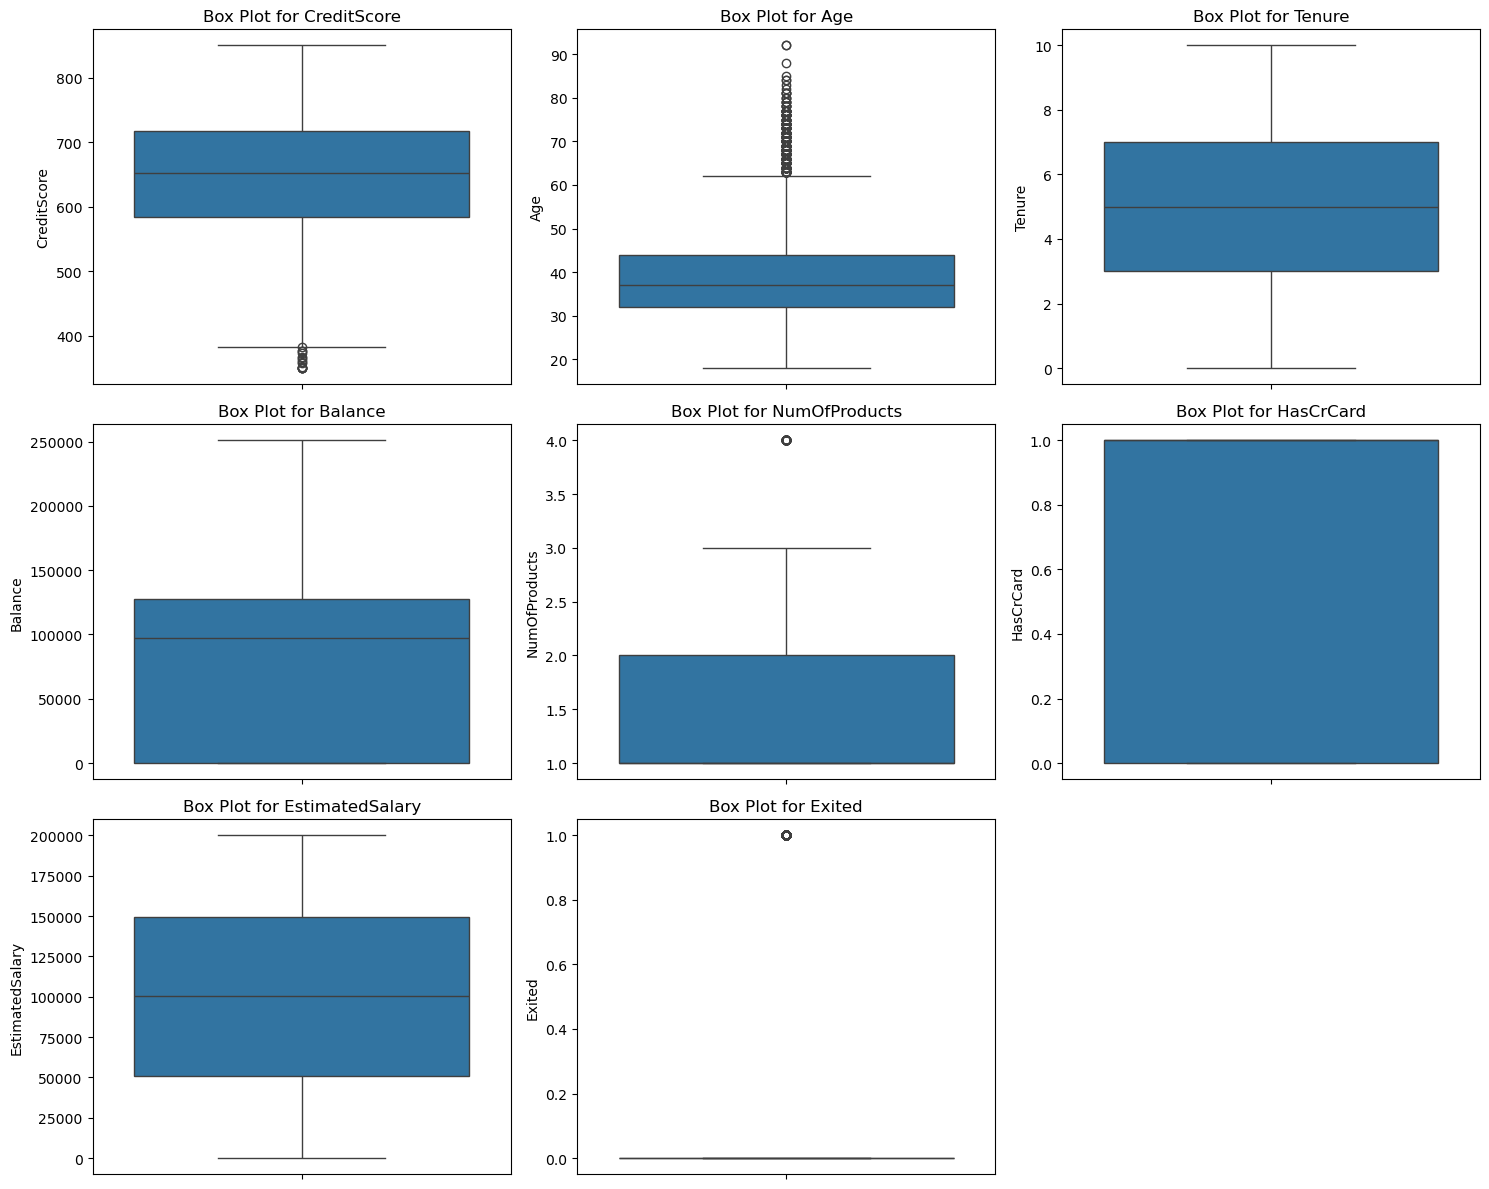

In [25]:
# Function to visualize outliers using box plots
def visualize_outliers(row_data_d):
    # Select numerical features for visualization
    numerical_features = row_data_d.select_dtypes(include=['float64', 'int64',]).columns

    # Calculate the number of rows and columns for the subplots
    num_features = len(numerical_features)
    num_cols = 3  # Number of columns for the subplot
    num_rows = (num_features // num_cols) + (num_features % num_cols > 0)  # Calculate required rows

    # Set up the matplotlib figure
    plt.figure(figsize=(15, num_rows * 4))  # Adjust height based on number of rows
    
    # Create a box plot for each numerical feature
    for i, feature in enumerate(numerical_features):
        plt.subplot(num_rows, num_cols, i + 1)  # Create subplot dynamically
        sns.boxplot(y=row_data[feature])  # Create box plot for the feature
        plt.title(f'Box Plot for {feature}')  # Set the title for the plot
        plt.ylabel(feature)  # Label the y-axis

    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()  # Display the plots

# Call the visualization function with your DataFrame
visualize_outliers(row_data_d)


#### This code defines a function to visualize outliers in numerical features of a DataFrame using box plots. It selects numerical columns,        calculates the required layout for subplots, and creates a box plot for each feature. The plots are dynamically arranged in a grid            format with appropriate titles and labels. Finally, the function displays all the box plots in a single figure. This visualization            helps to easily identify outliers and understand the distribution of the data for each numerical feature.

### **2.1.6.Remove the outliers and visualize the result using box plots** 


Shape of the dataset after removing outliers:  (9569, 11)



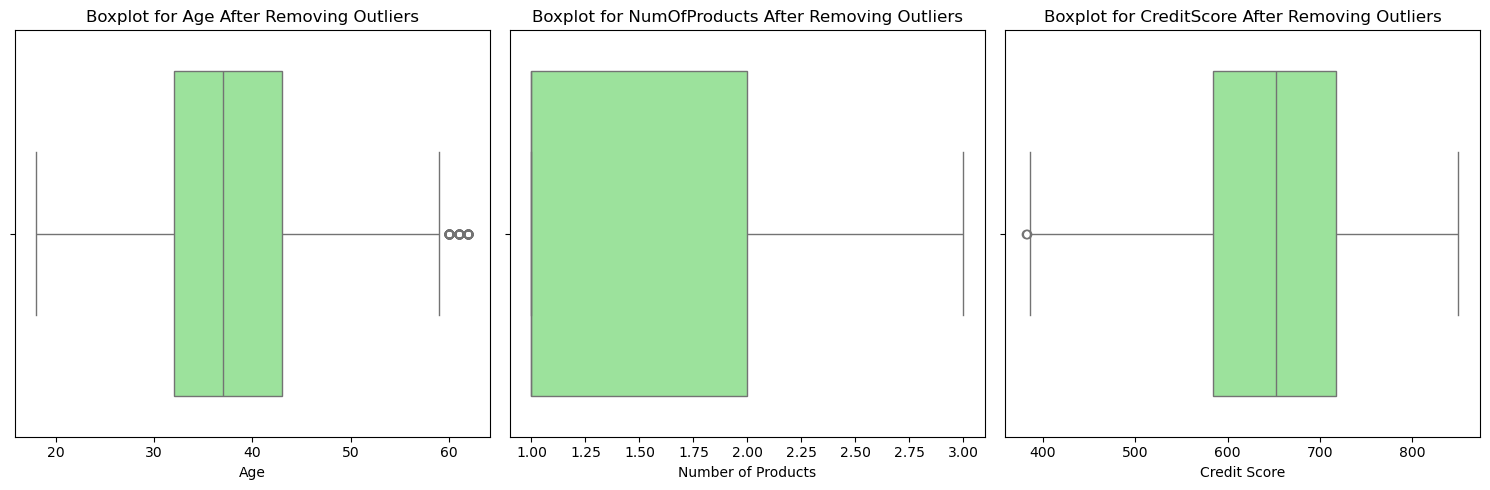

In [28]:
# Create a copy of the row_data_d DataFrame to preserve it for further use
row_data_c = row_data_d.copy()  

# Loop through the specified columns to remove outliers
for column in ['Age', 'NumOfProducts', 'CreditScore']:
    # Calculate the first quartile (Q1) and third quartile (Q3) for the current column
    Q1 = row_data_c[column].quantile(0.25)  # 25th percentile (first quartile)
    Q3 = row_data_c[column].quantile(0.75)  # 75th percentile (third quartile)
    
    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1  # IQR is the range between Q1 and Q3

    # Define lower and upper bounds to identify outliers
    lower_bound = Q1 - 1.5 * IQR  # Lower bound for outlier detection
    upper_bound = Q3 + 1.5 * IQR  # Upper bound for outlier detection

    # Filter the dataset to remove rows that have outliers in the current column
    row_data_c = row_data_c[(row_data_c[column] >= lower_bound) & (row_data_c[column] <= upper_bound)]

# Show the shape of the dataset after removing outliers
print("\nShape of the dataset after removing outliers: ", row_data_c.shape)  # Display the new shape

# Print a blank line for spacing after showing the data shape
print() 

# Create subplots to display boxplots for the cleaned data
fig, ax = plt.subplots(1, 3, figsize=(15, 5))  # Create a figure with 1 row and 3 columns for boxplots

# Boxplot for 'Age' without outliers
sns.boxplot(x=row_data_c['Age'], color='lightgreen', ax=ax[0])  # Create a boxplot for Age
ax[0].set_title('Boxplot for Age After Removing Outliers')  # Set the title for the Age plot
ax[0].set_xlabel('Age')  # Label the x-axis

# Boxplot for 'NumOfProducts' without outliers
sns.boxplot(x=row_data_c['NumOfProducts'], color='lightgreen', ax=ax[1])  # Create a boxplot for Number of Products
ax[1].set_title('Boxplot for NumOfProducts After Removing Outliers')  # Set the title for the NumOfProducts plot
ax[1].set_xlabel('Number of Products')  # Label the x-axis

# Boxplot for 'CreditScore' without outliers
sns.boxplot(x=row_data_c['CreditScore'], color='lightgreen', ax=ax[2])  # Create a boxplot for Credit Score
ax[2].set_title('Boxplot for CreditScore After Removing Outliers')  # Set the title for the CreditScore plot
ax[2].set_xlabel('Credit Score')  # Label the x-axis

# Adjust layout for better spacing of plots
plt.tight_layout()  # Automatically adjust subplot parameters to give specified padding

# Display the boxplots
plt.show()  # Show the combined boxplots


#### This code removes outliers from the specified columns ('Age', 'NumOfProducts', 'CreditScore') in a DataFrame by calculating the               Interquartile Range (IQR) and filtering out values that fall outside the defined bounds. After cleaning the dataset, it prints the new        shape of the DataFrame and creates box plots for each feature to visualize the distribution without outliers. This process helps ensure       that subsequent analyses are based on cleaner, more reliable data.

### 2.1.7.**Check Erroneous Data**

#### 2.1.7.1.**Check Dublicate Data & Erroneous Data**

In [32]:
# Check for duplicate rows in the entire DataFrame
duplicate_rows = row_data_c[row_data_c.duplicated()]

# Count the number of duplicate rows
duplicate_count = duplicate_rows.shape[0]

# Display the count of duplicate rows
print(f"\n -> Count of Duplicate Rows : {duplicate_count}")

# Function to count erroneous data in the DataFrame
def count_erroneous_data(row_data_c):
    # Initialize an empty dictionary to store erroneous data counts per column
    erroneous_counts = {}
    
    # Loop through each column in the DataFrame
    for column in row_data_c.columns:
        count = 0  # Initialize counter for erroneous data in the current column
        
        # Add counts for erroneous data to the dictionary if any found
        if count > 0:
            erroneous_counts[column] = count
    
    # Return the dictionary containing erroneous data counts
    return erroneous_counts

# Call the function to count erroneous data in the DataFrame
erroneous_counts = count_erroneous_data(row_data_c)

# Display the counts of erroneous data for each column
if erroneous_counts:
    for column, count in erroneous_counts.items():
        print(f"Count of Erroneous Data in '{column}': {count}")
else:
    print(" -> No erroneous data found : 0")



 -> Count of Duplicate Rows : 0
 -> No erroneous data found : 0


#### This code snippet checks for duplicate rows in a DataFrame and counts how many duplicates exist. It prints the total count of duplicate       rows found. Additionally, it defines a function to count erroneous data across all columns in the DataFrame, although the                     implementation currently lacks the logic to identify errors. After calling this function, it displays the counts of erroneous data or         No erroneous data found.Overall, this code helps in assessing the data quality by identifying duplicates and erroneous errors.

### 2.2.**Feature Engineering**

#### 2.2.1.**Transform Existing Features** 

##### 2.2.1.1.**Scaling Numerical Features( Standardization )**

In [37]:
# Create a copy of the row_data_d DataFrame to preserve it for further use
row_data_s = row_data_c.copy() 

# Identify specific numerical columns
numerical_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform only the specified numerical columns
row_data_s[numerical_cols] = scaler.fit_transform(row_data_s[numerical_cols])


#### This process is essential for preparing data for machine learning algorithms that are sensitive to the scale of the input features,           ensuring that all numerical features contribute equally to the model training.

##### 2.2.1.2.**One-Hot Encoding for Categorical Features**

In [40]:
#Convert categorical columns to strings
row_data_s[['Geography', 'Gender', 'IsActiveMember',]] = row_data_s[['Geography', 'Gender', 'IsActiveMember',]].astype(str)

#Define the categorical columns to one-hot encode
categorical_columns = ['Geography', 'Gender', 'IsActiveMember']

#One-hot encode the categorical columns
Final_df = pd.get_dummies(row_data_s, columns=categorical_columns, drop_first=True)

#Convert only the one-hot encoded columns to binary integers (0s and 1s)
encoded_columns = list(set(Final_df.columns) - set(row_data_s.columns))
Final_df[encoded_columns] = Final_df[encoded_columns].astype(int)
#Display the final transformed DataFrame
Final_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,IsActiveMember_1
0,-0.329398,0.485579,2,-1.224491,1,1,0.021668,1,0,0,0,1
1,-0.443835,0.371711,1,0.118270,1,0,0.216264,0,0,1,0,1
2,-1.546592,0.485579,8,1.333579,3,1,0.240411,1,0,0,0,0
3,0.502871,0.143974,1,-1.224491,2,0,-0.109102,0,0,0,0,0
4,2.073780,0.599447,2,0.786431,1,1,-0.365393,0,0,1,0,1


#### This preprocessing step is crucial for preparing categorical data for machine learning algorithms, which typically require numerical         input. One-hot encoding allows the model to interpret categorical variables effectively.

## **2.3.Data Splitting**

In [43]:
# Set the target variable
target = Final_df['Exited'] 

# Split the data into features (X) and target [Exited(Y)]
X = Final_df.drop(columns=['Exited'])  # Drop the target column from features
y = target

# Split the dataset into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display the shapes of the resulting datasets
print("\nTraining data shape (X_train)    : ", X_train.shape)
print("Testing data shape (X_test)      : ", X_test.shape)
print("Training target shape (y_train)  : ", y_train.shape)
print("Testing target shape (y_test)    : ", y_test.shape)


Training data shape (X_train)    :  (6698, 11)
Testing data shape (X_test)      :  (2871, 11)
Training target shape (y_train)  :  (6698,)
Testing target shape (y_test)    :  (2871,)


#### The resulting shapes will indicate how many samples and features are present in each dataset, which is essential for understanding the       size of the training and testing sets before proceeding with model training and evaluation.

# 03.**Exploratory Data Analysis (EDA)**

## **3.1.Descriptive Statistics**

### 3.1.1.**Measures of Central Tendency**

In [48]:
# Define the features for which central tendency measures will be calculated
features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'NumOfProducts']

# Prepare lists to hold the central tendency statistics before and after scaling
before_stats = []
after_stats = []

# Calculate statistics for each feature
for feature in features:
    # Calculate mean, median, and mode before scaling and store them in the before_stats list
    mean_before = row_data_c[feature].mean()           # Mean before scaling
    median_before = row_data_c[feature].median()       # Median before scaling
    mode_before = row_data_c[feature].mode()[0]        # Mode before scaling (using first mode if multiple modes)
    before_stats.append([feature, mean_before, median_before, mode_before])
    
    # Calculate mean, median, and mode after scaling and store them in the after_stats list
    mean_after = Final_df[feature].mean()              # Mean after scaling
    median_after = Final_df[feature].median()          # Median after scaling
    mode_after = Final_df[feature].mode()[0]           # Mode after scaling
    after_stats.append([feature, mean_after, median_after, mode_after])

# Convert the lists into DataFrames for clearer presentation
before_df = pd.DataFrame(before_stats, columns=['Feature', 'Mean', 'Median', 'Mode'])
after_df = pd.DataFrame(after_stats, columns=['Feature', 'Mean', 'Median', 'Mode'])

# Set the Feature column as the index for better alignment of statistics by feature
before_df.set_index('Feature', inplace=True)
after_df.set_index('Feature', inplace=True)

# Print the Before Scaling table with centered heading for emphasis
print("\n" + " " * 15 + "Before Scaling" + "\n")
print(before_df)

# Add a line space between the tables for separation
print("\n" * 1)

# Print the After Scaling table with centered heading for emphasis
print(" " * 16 + "After Scaling" + "\n")
print(after_df)



               Before Scaling

                          Mean     Median      Mode
Feature                                            
CreditScore         650.662661     652.00    850.00
Age                  37.735605      37.00     38.00
Balance           76426.067825   97086.40      0.00
EstimatedSalary  100102.487244  100130.95  24924.92
NumOfProducts         1.515937       1.00      1.00


                After Scaling

                         Mean    Median      Mode
Feature                                          
CreditScore      5.130996e-16  0.013913  2.073780
Age              1.958466e-16 -0.083762  0.030106
Balance          0.000000e+00  0.331018 -1.224491
EstimatedSalary -1.410838e-16  0.000495 -1.306920
NumOfProducts    1.515937e+00  1.000000  1.000000


#### **Central Tendency Measures:** <font color = #82e0aa >Before scaling, features like CreditScore and Balance exhibit skewed distributions, with medians differing from means. After scaling, most means are near zero, indicating standardization. NumOfProducts remains unaffected due to its categorical nature, while other features are centered around zero with reduced skew.</font>

### **3.1.2.Measures of Dispersion**

In [51]:
# Define the features for which we want to calculate variability statistics
features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'NumOfProducts']

# Prepare lists to hold the statistics for before and after scaling
variability_stats_before = []
variability_stats_after = []

# Calculate variability statistics for each feature
for feature in features:
    # Calculate statistics before scaling
    range_before = row_data_c[feature].max() - row_data[feature].min()  # Range
    variance_before = row_data_c[feature].var()  # Variance
    std_dev_before = row_data_c[feature].std()  # Standard Deviation
    q1_before = row_data_c[feature].quantile(0.25)  # First Quartile
    q3_before = row_data_c[feature].quantile(0.75)  # Third Quartile
    iqr_before = q3_before - q1_before  # Interquartile Range
    
    # Append the statistics before scaling to the list
    variability_stats_before.append([feature, range_before, variance_before, std_dev_before, iqr_before])
    
    # Calculate statistics after scaling
    range_after = Final_df[feature].max() - Final_df[feature].min()  # Range
    variance_after = Final_df[feature].var()  # Variance
    std_dev_after = Final_df[feature].std()  # Standard Deviation
    q1_after = Final_df[feature].quantile(0.25)  # First Quartile
    q3_after = Final_df[feature].quantile(0.75)  # Third Quartile
    iqr_after = q3_after - q1_after  # Interquartile Range
    
    # Append the statistics after scaling to the list
    variability_stats_after.append([feature, range_after, variance_after, std_dev_after, iqr_after])

# Create DataFrames for variability statistics before and after scaling
variability_df_before = pd.DataFrame(variability_stats_before, columns=['Feature', 'Range', 'Variance', 'Std Dev', 'IQR'])
variability_df_after = pd.DataFrame(variability_stats_after, columns=['Feature', 'Range', 'Variance', 'Std Dev', 'IQR'])

# Set the index to be the Feature column for better alignment
variability_df_before.set_index('Feature', inplace=True)
variability_df_after.set_index('Feature', inplace=True)

# Print the Variability Statistics tables with centered headings
print("\n" + " " * 15 + "Measures of Variability Before Scaling" + "\n")
print(variability_df_before)

print("\n" + " " * 15 + "Measures of Variability After Scaling" + "\n")
print(variability_df_after)


               Measures of Variability Before Scaling

                     Range      Variance       Std Dev        IQR
Feature                                                          
CreditScore         500.00  9.240542e+03     96.127736     133.00
Age                  44.00  7.713306e+01      8.782543      11.00
Balance          250898.09  3.895984e+09  62417.820208  127609.59
EstimatedSalary  199980.90  3.309206e+09  57525.696669   98455.11
NumOfProducts         2.00  3.022387e-01      0.549762       1.00

               Measures of Variability After Scaling

                    Range  Variance   Std Dev       IQR
Feature                                                
CreditScore      4.868776  1.000105  1.000052  1.383648
Age              5.010200  1.000105  1.000052  1.252550
Balance          4.019865  1.000105  1.000052  2.044548
EstimatedSalary  3.476557  1.000105  1.000052  1.711587
NumOfProducts    2.000000  0.302239  0.549762  1.000000


#### **Measures of Dispersion :** <font color = #82e0aa>Before scaling, features like Balance and EstimatedSalary show high variability, with large ranges and standard deviations. After scaling, all features (except NumOfProducts) have standardized variance and reduced ranges, ensuring comparability. This helps prevent features with large spreads from dominating machine learning models.</font>

### **3.1.3.Measures for Shape of the Distribution**

In [54]:
# Define the features for which we want to calculate statistics
features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'NumOfProducts']

# Initialize lists to hold the statistics
shape_stats = []
percentile_stats = []
frequency_tables = {}

# Calculate measures of shape, percentiles, and frequency distribution
for feature in features:
    # Calculate skewness and kurtosis
    skewness = Final_df[feature].skew()  # Skewness
    kurtosis = Final_df[feature].kurtosis()  # Kurtosis
    shape_stats.append([feature, skewness, kurtosis])
    
    # Calculate percentiles and quartiles
    q1 = Final_df[feature].quantile(0.25)  # 25th percentile
    q2 = Final_df[feature].quantile(0.50)  # 50th percentile (median)
    q3 = Final_df[feature].quantile(0.75)  # 75th percentile
    percentile_stats.append([feature, q1, q2, q3])
    
    # Calculate frequency distribution
    frequency_table = Final_df[feature].value_counts().sort_index()  # Frequency table
    frequency_tables[feature] = frequency_table

# Create DataFrames for shape statistics and percentiles
shape_df = pd.DataFrame(shape_stats, columns=['Feature', 'Skewness', 'Kurtosis'])
percentile_df = pd.DataFrame(percentile_stats, columns=['Feature', 'Q1', 'Q2 (Median)', 'Q3'])

# Set the index to be the Feature column for better alignment
shape_df.set_index('Feature', inplace=True)
percentile_df.set_index('Feature', inplace=True)

# Print the Measures of Shape
print("\n" + " " * 15 + "Measures of Shape" + "\n")
print(shape_df)

# Print the Percentiles and Quartiles
print("\n" + " " * 15 + "Percentiles and Quartiles" + "\n")
print(percentile_df)


               Measures of Shape

                 Skewness  Kurtosis
Feature                            
CreditScore     -0.047550 -0.483611
Age              0.495474  0.014877
Balance         -0.138027 -1.487863
EstimatedSalary -0.000083 -1.182484
NumOfProducts    0.410717 -0.932140

               Percentiles and Quartiles

                       Q1  Q2 (Median)        Q3
Feature                                         
CreditScore     -0.693516     0.013913  0.690132
Age             -0.653103    -0.083762  0.599447
Balance         -1.224491     0.331018  0.820057
EstimatedSalary -0.853341     0.000495  0.858246
NumOfProducts    1.000000     1.000000  2.000000


#### **Measures of Shape :** <font color = #82e0aa >After scaling, skewness values indicate near-symmetrical distributions for most features. Age shows slight right skew, while Balance and CreditScore exhibit minimal negative skew. Kurtosis values are close to zero, indicating normally distributed data with few outliers.</font>



#### **Percentiles and Quartiles:**<font color = #82e0aa > Post-scaling, Q1, Q2 (median), and Q3 values align closely around zero for most features, confirming effective normalization. NumOfProducts remains consistent, with Q1 and Q2 at 1.0. These quartiles reveal that most features are now symmetrically distributed across the transformed range.</font>

### **3.1.4.key Summary Statistics**

In [58]:
# Generate descriptive statistics for the DataFrame
Final_df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,IsActiveMember_1
count,9.569000e+03,9.569000e+03,9569.000000,9569.000000,9569.000000,9569.000000,9.569000e+03,9569.000000,9569.000000,9569.000000,9569.000000,9569.000000
mean,5.130996e-16,1.958466e-16,5.014840,0.000000,1.515937,0.705194,-1.410838e-16,0.197722,0.250601,0.247988,0.547288,0.503710
std,1.000052e+00,1.000052e+00,2.888173,1.000052,0.549762,0.455979,1.000052e+00,0.398302,0.433382,0.431868,0.497785,0.500012
min,-2.794997e+00,-2.247258e+00,0.000000,-1.224491,1.000000,0.000000,-1.740025e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-6.935162e-01,-6.531029e-01,3.000000,-1.224491,1.000000,0.000000,-8.533409e-01,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.391283e-02,-8.376196e-02,5.000000,0.331018,1.000000,1.000000,4.948092e-04,0.000000,0.000000,0.000000,1.000000,1.000000
75%,6.901318e-01,5.994472e-01,7.000000,0.820057,2.000000,1.000000,8.582464e-01,0.000000,1.000000,0.000000,1.000000,1.000000
max,2.073780e+00,2.762943e+00,10.000000,2.795374,3.000000,1.000000,1.736532e+00,1.000000,1.000000,1.000000,1.000000,1.000000


#### **Summary of Descriptive Statistics:**<font color = #82e0aa > After scaling, means are close to zero, with standard deviations normalized to one, ensuring balanced feature ranges. Features retain consistent observation counts, and binary indicators (e.g., HasCrCard) remain unchanged. The transformed dataset is now optimized for modeling, minimizing scaling-related distortions.</font >

## **3.2.Visualizations**

### 3.2.1.Bar Charts for Categorical Columns by Exited Rate 

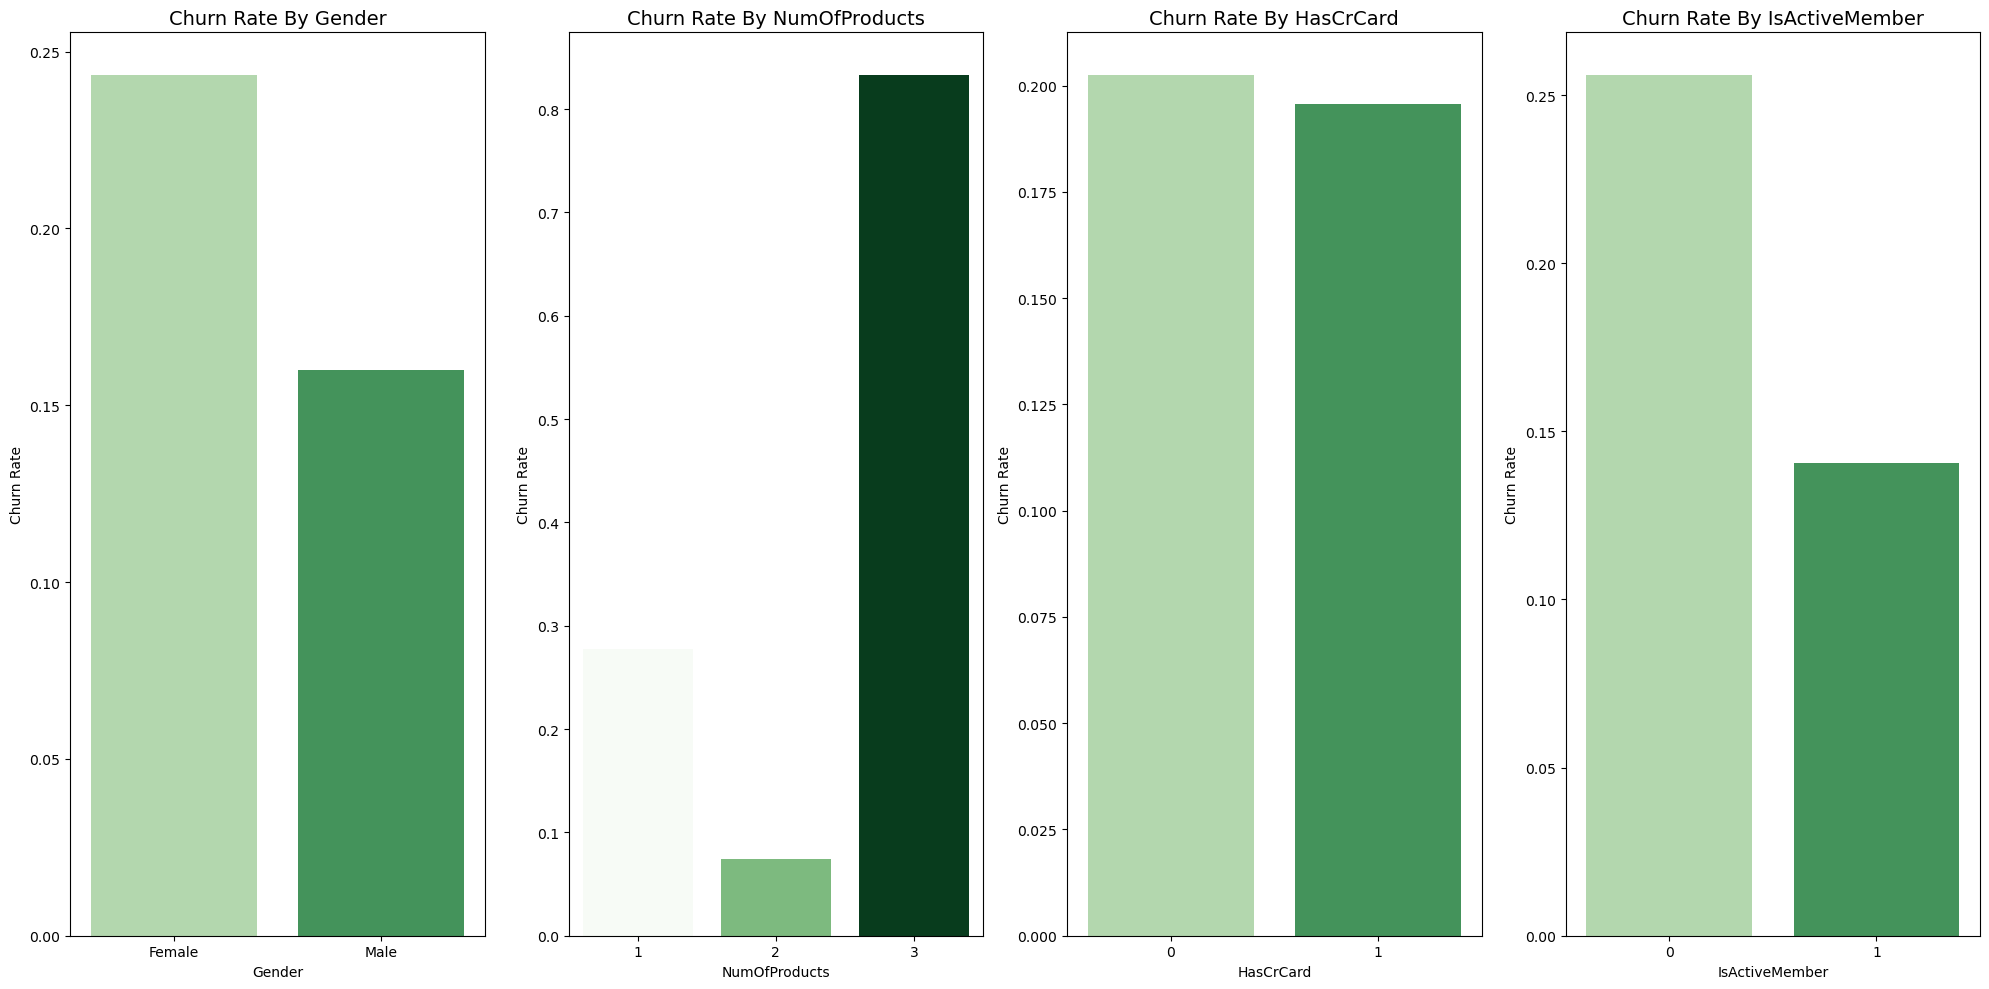

In [62]:
# List of categorical columns to analyze
cat_c = ['Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

# Create a figure with 1 row and 4 columns for subplots

fig, axes = plt.subplots(1, 4, figsize=(20, 10))

# Loop through each categorical column

for i, col in enumerate(cat_c):
   
    # Calculate the average churn rate for each category, setting observed=True to avoid warnings
    ChurnRate_ByCol = row_data_c.groupby(col, observed=True)['Exited'].mean().reset_index()
    
    # Create a bar plot for churn rate, using a green color palette
    sns.barplot(data=ChurnRate_ByCol, x=col, y='Exited', hue=col, palette='Greens', ax=axes[i], legend=False)
    
    # Set titles and labels for each subplot
    axes[i].set_title(f'Churn Rate By {col}', fontsize=14)
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xlabel(col)

# Adjust layout for better spacing of plots

plt.tight_layout()
# Display the plots
plt.show()

#### The visualizations display churn rates across four categorical variables: ''Gender'',''HasCrCard'',''Num Of Products''  and ''Is Active Member''. Each bar plot highlights the average churn rate within each category, offering insights into customer behavior. For instance, examining ''Is Active Member'' and ''Num Of Products'' shows clear churn trends, where activity status and product variety impact retention rates. The ''Greens'' color palette provides visual emphasis on churn likelihood across these categories.

### 3.2.2.KDE plots for balance and Credit Score Distributions by Exited

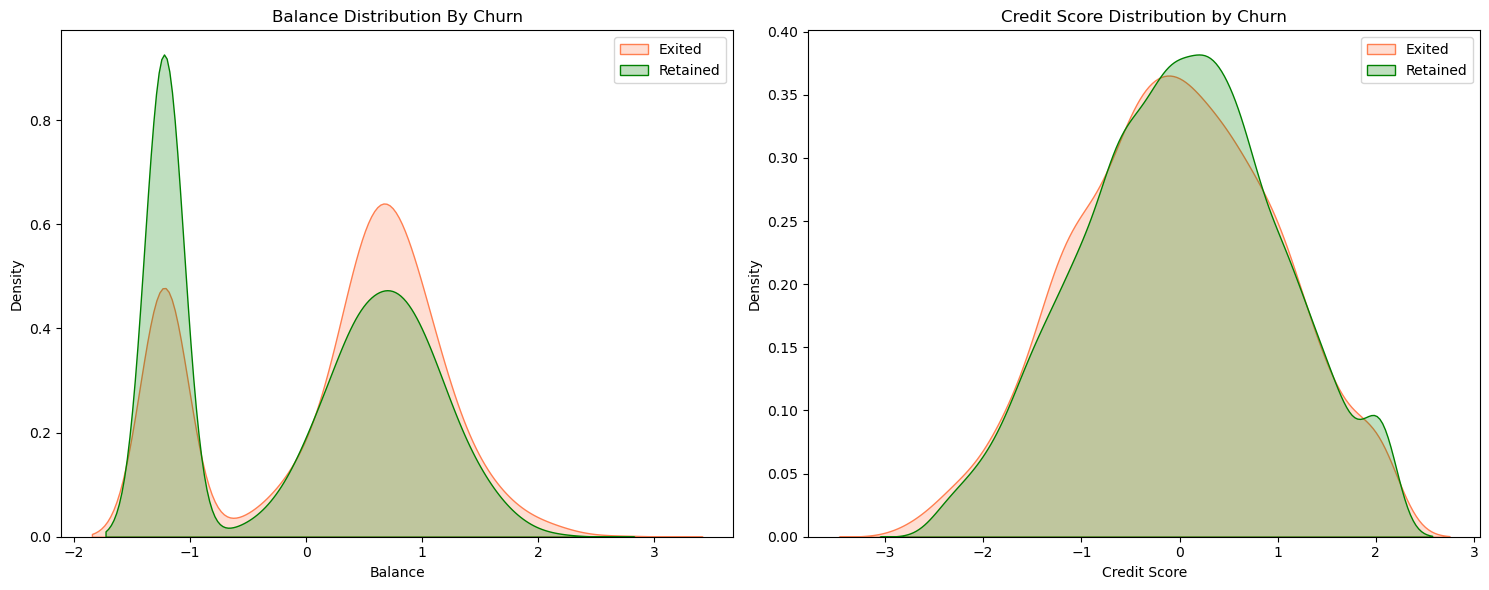

In [65]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Balance Distribution by Churn
sns.kdeplot(Final_df[Final_df['Exited'] == 1]['Balance'], label='Exited', fill=True, color='coral', ax=axes[0])
sns.kdeplot(Final_df[Final_df['Exited'] == 0]['Balance'], label='Retained', fill=True, color='green', ax=axes[0])
axes[0].set_title('Balance Distribution By Churn')
axes[0].legend(loc='upper right', frameon=True)

# Credit Score Distribution by Churn
sns.kdeplot(Final_df[Final_df['Exited'] == 1]['CreditScore'], label='Exited', fill=True, color='coral', ax=axes[1])
sns.kdeplot(Final_df[Final_df['Exited'] == 0]['CreditScore'], label='Retained', fill=True, color='green', ax=axes[1])
axes[1].set_title('Credit Score Distribution by Churn')
axes[1].set_xlabel('Credit Score')
axes[1].legend(loc='upper right', frameon=True)

# Adjust layout
plt.tight_layout()
plt.show()


#### The 2 KDE plots present Balance Distribution by Churn and Credit Score Distribution by Churn for exited and retained customers. In the Balance Distribution plot on the left, customers who have churned (Exited) show a higher density around specific balance levels, with two distinct peaks. Retained customers have a strong peak at lower balance levels, indicating that low balance is more common among retained users.The Credit Score Distribution plot on the right shows that retained customers generally have higher credit scores, with a slight shift in the distribution. This suggests that higher credit scores may be associated with customer retention, while lower credit scores have a modest overlap with churned users. These insights indicate that both balance and credit score are key indicators of churn likelihood.

### 3.2.3.Bar chart for Count of Customers By Tenure and Exited (Left plot) 

### 3.2.4.Pivot table for Gender and Geography (Right plot)

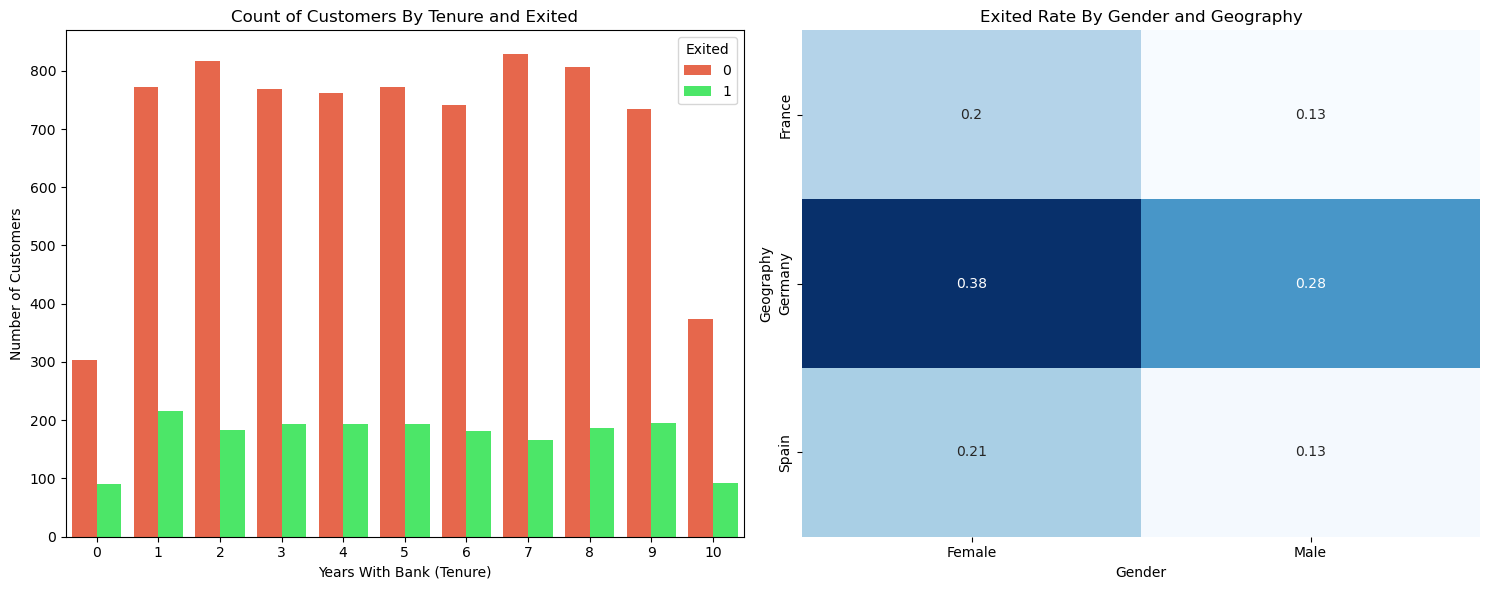

In [69]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # Adjust figsize as needed
# Count plot for the number of customers based on tenure and churn status
sns.countplot(
    data=Final_df,  # The DataFrame containing the data
    x='Tenure',  # The variable to be plotted on the x-axis (Years with Bank)
    hue='Exited',  # Categorical variable for coloring bars (Exited vs. Retained)
    palette=['#FF5733', '#33FF57'],  # Custom bright colors: red for Exited, green for Retained
    ax=axes[0]  # Specify the first subplot
)
# Set the title and labels for the count plot
axes[0].set_title('Count of Customers By Tenure and Exited')
axes[0].set_xlabel('Years With Bank (Tenure)')
axes[0].set_ylabel('Number of Customers')
# Pivot table for churn rate by gender and geography
pivot = pd.pivot_table(row_data, values='Exited', index='Geography', columns='Gender', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='Blues', cbar=False, ax=axes[1])  # Specify the second subplot
axes[1].set_title('Exited Rate By Gender and Geography')  # Set title for the heatmap
# Adjust layout to prevent overlap
plt.tight_layout()
# Display the combined plots
plt.show()

#### **3.2.3.Count of Customers by Tenure and Exited (Left Plot)**: This bar chart shows customer churn status over varying years of tenure with the bank. Generally, there is a consistent churn rate across different tenure groups, with more customers remaining (retained) compared to those who exit. The lowest customer count for retention and churn is seen at the 0 and 10-year tenures, which may reflect patterns of early dissatisfaction or lifecycle maturity. Mid-tenure customers appear to be more stable in retention.

#### **3.2.4.Exited Rate by Gender and Geography (Right Plot)**:The heatmap presents churn rates segmented by gender and geography. Notably, Germany shows the highest churn rate, especially among females (0.38), while other regions (France and Spain) have significantly lower churn rates across both genders. Males across all regions show lower churn rates compared to females. This visualization suggests that churn likelihood is influenced by both geography and gender, with German females displaying a particularly high exit rate.These graphs suggest that customer tenure, geography, and gender are crucial factors in understanding customer churn.</font>

### 3.2.5.Histogram for Churn Rate by Age


### 3.2.6.Scatter Plot for Age vs Balance

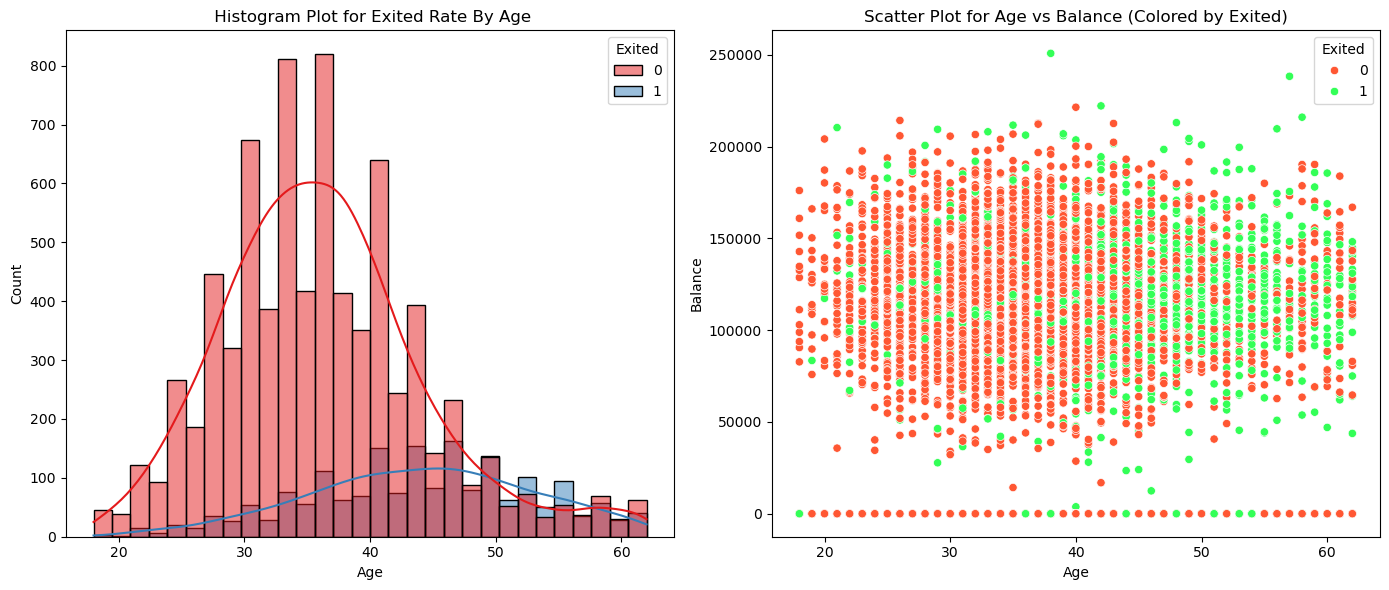

In [74]:
# Create a figure with 1 row and 2 columns for the histogram and scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Adjust figsize as needed

# Histogram to visualize the distribution of Age based on the Churn status
# Create the histogram using Plotly and convert it to a Matplotlib figure
px_histogram = px.histogram(
    row_data_c, 
    x='Age',
    color='Exited',
    barmode='overlay',
    title='Exited Rate By Age',
    labels={'Exited': 'Exited (1 = Yes, 0 = No)'},
    color_discrete_sequence=px.colors.qualitative.Set1  # Using a bright qualitative color palette
)

# Instead of saving, we can display the Plotly figure directly in the notebook
# or extract the data and use Matplotlib
# Using Matplotlib to create the histogram
sns.histplot(
    data=row_data_c, 
    x='Age', 
    hue='Exited', 
    bins=30, 
    palette='Set1', 
    ax=axes[0], 
    kde=True  # Optionally include a kernel density estimate
)

# Set the title for the histogram plot
axes[0].set_title(' Histogram Plot for Exited Rate By Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Scatter plot to visualize the relationship between Age and Balance
sns.scatterplot(
    data=row_data_c,  # The DataFrame containing the data
    x='Age',  # Variable for the x-axis (Age)
    y='Balance',  # Variable for the y-axis (Balance)
    hue='Exited',  # Categorical variable for coloring points (Exited vs. Retained)
    palette=['#FF5733', '#33FF57'],  # Custom bright colors: red for Exited, green for Retained
    ax=axes[1]  # Specify the second subplot
)

# Set the title of the scatter plot
axes[1].set_title('Scatter Plot for Age vs Balance (Colored by Exited)')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the combined plots
plt.show()


#### **3.2.5.Histogram Plot for Exited Rate by Age (Left Plot)**: This histogram displays the distribution of customer age along with churn status. A clear peak is visible around ages 30 to 40, representing the highest number of customers in this age range. Churn frequency is higher among older customers, particularly after 40, suggesting that as customers age, their likelihood of exiting the bank increases. The kernel density estimate (KDE) lines for each group (exited vs. retained) reinforce this trend, with a noticeable rightward shift for exited customers.



#### **3.2.6.Scatter Plot for Age vs Balance(Colored by Exited/Right Plot)**:This scatter plot examines the relationship between customer age and account balance, with different colors indicating churn status. There is a significant cluster of retained customers (green) across various age groups, with many having substantial balances above zero. Churned customers (red) are also scattered widely but appear denser in the lower balance range, suggesting that customers with low balances are more likely to churn across all age groups.These insights suggest a correlation between age, balance, and churn tendency, valuable for identifying at-risk customer segments.

### **3.2.7.Histograms for Selected Features**

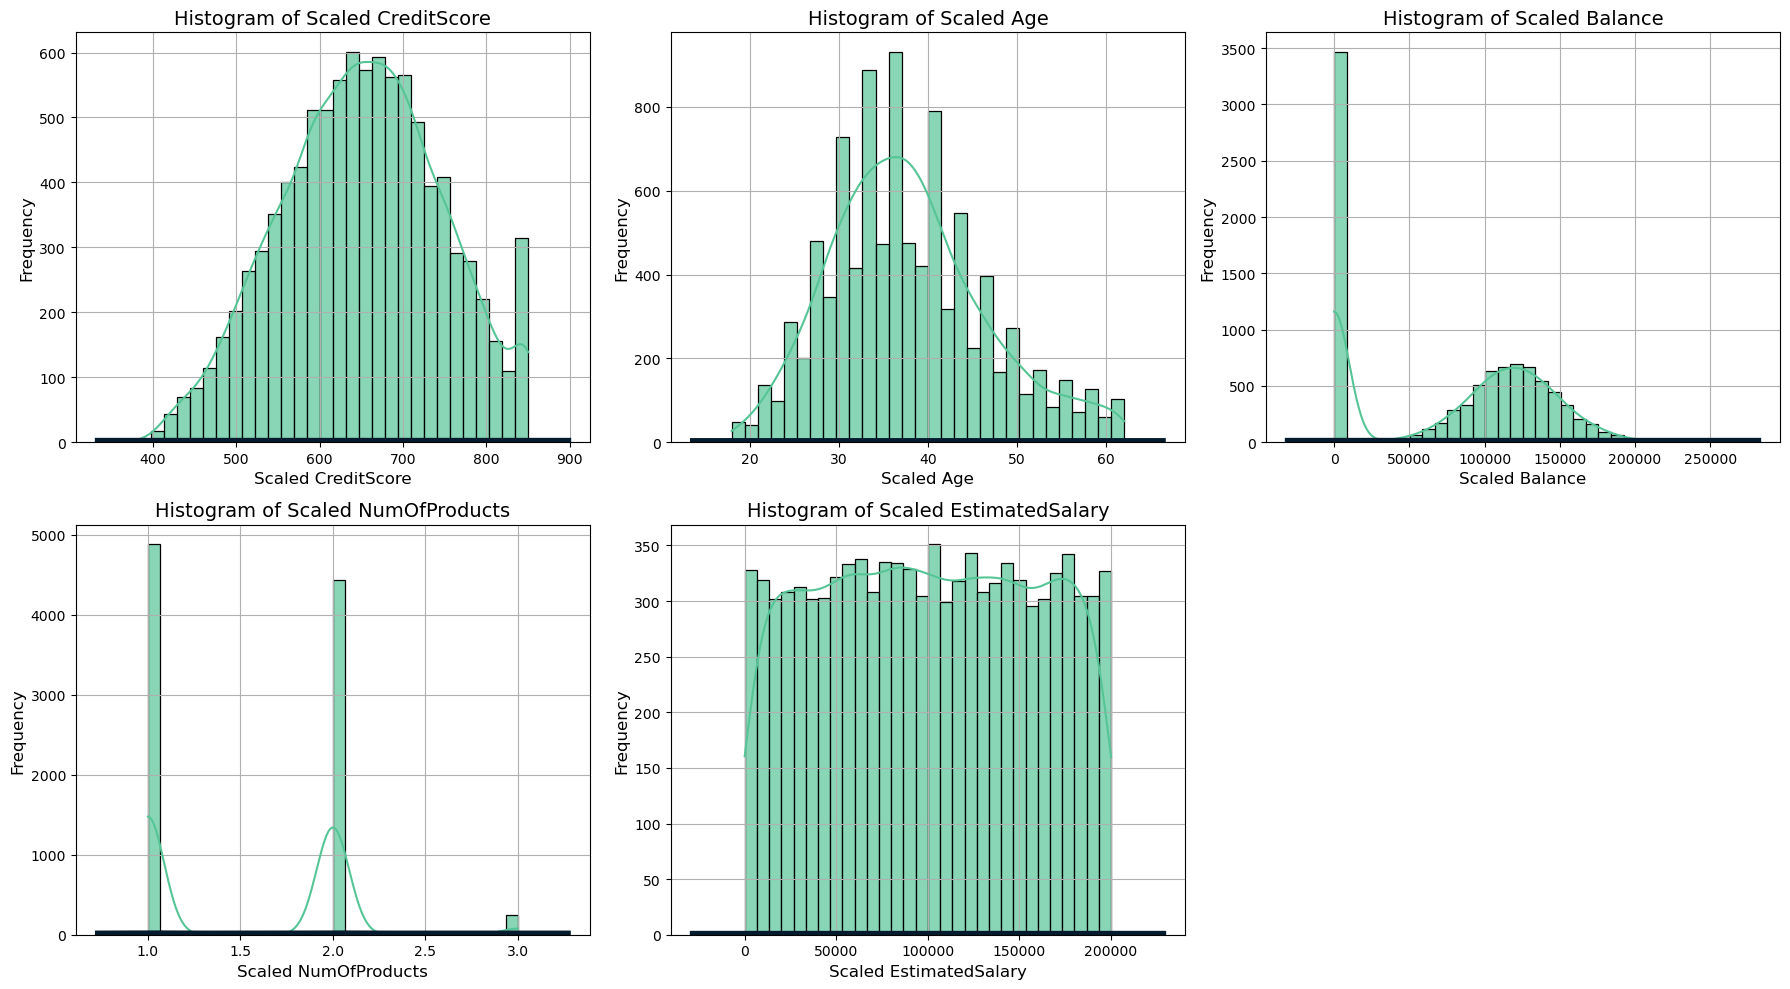

In [78]:
# List of scaled features to plot histograms and KDEs
scaled_features = ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'EstimatedSalary']
# Calculate the number of features for subplot layout
num_features = len(scaled_features)
# Create a figure with a specified size; adjust height based on the number of features
fig = plt.figure(figsize=(18, 5 * (num_features // 3 + (num_features % 3 > 0))))
# Create a grid layout with 3 columns for subplots
gs = GridSpec((num_features + 2) // 3, 3, figure=fig)
# Iterate over each feature to create histograms
for i, feature in enumerate(scaled_features):
    # Add a subplot in the correct position in the grid
    ax = fig.add_subplot(gs[i // 3, i % 3])   
    # Create a histogram with a KDE overlay for the current feature
    sns.histplot(
        data=row_data_c,            # Data source
        x=feature,                # Feature to plot on the x-axis
        bins=30,                  # Number of bins for the histogram
        kde=True,                 # Enable KDE overlay
        color='#56c596',          # Color of the histogram
        ax=ax,                    # Axes to plot on
        edgecolor='black',        # Color of the edges of the bars
        alpha=0.7                 # Transparency of the histogram bars
    )

    # Set the title for the subplot
    ax.set_title(f'Histogram of Scaled {feature}', fontsize=14)
    # Set the x-axis label
    ax.set_xlabel(f'Scaled {feature}', fontsize=12)    
    # Set the y-axis label
    ax.set_ylabel('Frequency', fontsize=12)   
    # Enable grid lines for better visibility of the plot
    ax.grid(True)
    # Plot the KDE line with a darker color for clarity
    sns.kdeplot(
        data=row_data_c[feature],   # Data source for the KDE
        ax=ax,                    # Axes to plot on
        color='#041B2D',          # Color of the KDE line
        linewidth=6               # Width of the KDE line
    )

# Hide any unused subplots if the number of features is not a multiple of 3
for j in range(num_features, (num_features + 2) // 3 * 3):
    try:   
        fig.delaxes(fig.axes[j])  # Remove the unused axes
    except IndexError:
        break  # Break if the index is out of range
# Adjust the layout to prevent overlap between subplots
plt.tight_layout()
# Display the plot
plt.show()

#### **Analysis of distinct patterns:** credit scores follow a normal distribution around 650-750 with outliers below 500 and above 850, ages concentrate between 30-50 years showing a right-skewed distribution, account balances show two distinct peaks at zero and 150,000 suggesting different wealth segments, product usage primarily splits between one or two items per customer with limited cross-product engagement, and salary distributions remain uniform across ranges, indicating diverse income levels within the customer base.

### **3.2.8.Correlation Matrix Heatmap**

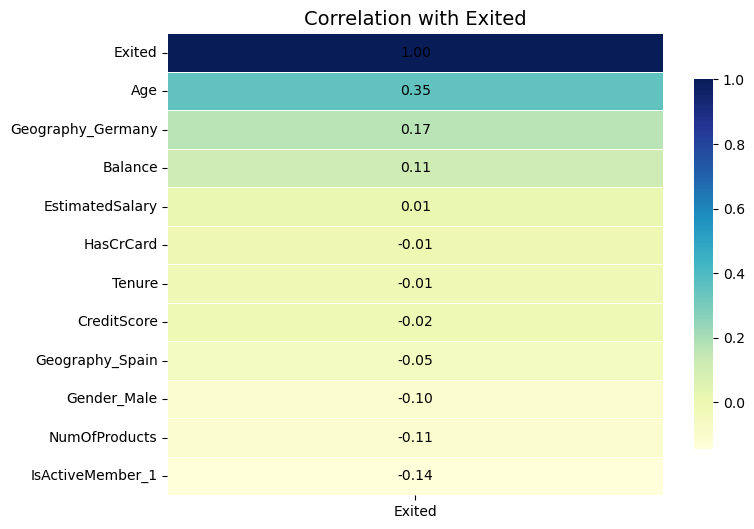

In [81]:
# Calculate correlation matrix
correlation_matrix = Final_df.corr()

# Create a heatmap focused on the 'Exited' column with a light color palette
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix[['Exited']].sort_values(by='Exited', ascending=False), 
            annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10, "color": "black"})  # Dark font color for contrast
plt.title('Correlation with Exited', fontsize=14)
plt.show()


#### The analysis reveals that customer age, region, and account balance are moderately linked to churn. Older customers and those from Germany show a higher likelihood of exiting, while active membership and holding more products are associated with better retention. Balance has a slight positive correlation with churn, indicating some high-balance customers may still leave, possibly due to unmet expectations. Features like estimated salary, credit score, and tenure have minimal impact. These insights suggest targeting engagement efforts towards older customers and enhancing product cross-selling to reduce churn.

# **4.Model Building**

## **4.1.Model Selection (Classification Problem)**

### **4.1.1.Random Forest Algorithm vs Logistic Regression Algorithm**

In [86]:
# Model Selection: Choosing Random Forest and Logistic Regression for classification
# Initializing models with random_state for reproducibility
rfc = RandomForestClassifier(random_state=42)
log_reg = LogisticRegression(random_state=42, max_iter=1000)


#### The code selects **Random Forest** and **Logistic Regression** as classification models for their complementary strengths: Random Forest’s robust ensemble method, which combines multiple decision trees to capture complex patterns, and Logistic Regression’s linear approach, which provides simplicity and interpretability. Both models are initialized with a random_state of 42 to ensure reproducible results, allowing consistent outputs across runs. Additionally, Logistic Regression’s max_iter is set to 1000 to allow sufficient iterations for convergence, ensuring accurate model optimization. This approach balances complexity and interpretability, leveraging the strengths of each model for the classification task.

### 4.1.2.Model Training

In [89]:
# Model Training: Training both models on the training dataset
# Training Random Forest
rfc.fit(X_train, y_train)

# Training Logistic Regression
log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

#### The training phase fits both models to the training data, allowing them to learn patterns between customer attributes and churn. Random Forest builds multiple decision trees for robust predictions through majority voting, while Logistic Regression adjusts weights to find linear relationships, providing probability outputs with sufficient iterations for optimal convergence.

### 4.1.3.Model Evaluation: 

In [92]:
# Model Evaluation for Random Forest
# Making predictions on the test set
y_pred_rf = rfc.predict(X_test)

# Calculating evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Displaying results for Random Forest
print("\nRandom Forest Evaluation:")
print(f"\nAccuracy: {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1 Score: {f1_rf:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Model Evaluation for Logistic Regression
# Making predictions on the test set
y_pred_lr = log_reg.predict(X_test)

# Calculating evaluation metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# Displaying results for Logistic Regression
print("\nLogistic Regression Evaluation:")
print(f"\nAccuracy: {accuracy_lr:.3f}")
print(f"Precision: {precision_lr:.3f}")
print(f"Recall: {recall_lr:.3f}")
print(f"F1 Score: {f1_lr:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))



Random Forest Evaluation:

Accuracy: 0.859
Precision: 0.746
Recall: 0.442
F1 Score: 0.555

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      2299
           1       0.75      0.44      0.56       572

    accuracy                           0.86      2871
   macro avg       0.81      0.70      0.74      2871
weighted avg       0.85      0.86      0.84      2871


Logistic Regression Evaluation:

Accuracy: 0.825
Precision: 0.647
Recall: 0.273
F1 Score: 0.384

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90      2299
           1       0.65      0.27      0.38       572

    accuracy                           0.83      2871
   macro avg       0.74      0.62      0.64      2871
weighted avg       0.80      0.83      0.80      2871



#### Both models were evaluated on test data, with Random Forest outperforming Logistic Regression across all metrics. Random Forest achieved higher accuracy (0.859), precision (0.746), recall (0.442), and F1 score (0.555), demonstrating better ability to identify churn cases. While Logistic Regression showed decent accuracy (0.825), its lower precision (0.647), recall (0.273), and F1 score (0.384) indicate it struggles with complex patterns, particularly in identifying positive churn cases.

# **05.Model Optimization**

## 5.1.Hyperparameter Tuning( Random Search) for Random Forest Algorithm

In [96]:
# Split the data into features (X) and target (y)
X = Final_df.drop('Exited', axis=1)  # Features
y = Final_df['Exited']  # Target variable
# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
# Splitting the resampled dataset into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)
# Optimized parameter grid for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(200, 500),               # Reduced range for efficiency
    'max_depth': [20, 30, 40, None],                 # Allow unpruned trees if needed
    'min_samples_split': randint(2, 10),             # Adjusted range for splitting
    'min_samples_leaf': randint(1, 4),               # Limit leaf size for generalization
    'max_features': ['sqrt', 'log2'],                # Feature selection methods
    'class_weight': ['balanced', None],              # Balanced weight for classes
    'bootstrap': [True]                              # Only use bootstrapping to avoid OOB error
}

# Initialize the Random Forest Classifier without oob_score
rfc = RandomForestClassifier(random_state=42, n_jobs=-1)
# Initialize RandomizedSearchCV with 5-fold CV
random_search = RandomizedSearchCV(
    estimator=rfc, 
    param_distributions=param_distributions, 
    n_iter=50,  # Increased number of iterations for broader exploration
    cv=5,       # Reduced CV folds for efficiency
    n_jobs=-1, 
    verbose=2, 
    scoring='f1', 
    random_state=42
)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)
# Best Parameters from RandomizedSearch
print("Best Parameters:", random_search.best_params_)
# Best Model
best_model = random_search.best_estimator_
# Predictions and evaluation on the test set
y_pred_best = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_best)
print(f"Optimized Accuracy: {accuracy:.3f}")
print("\nOptimized Classification Report:\n", classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 366}
Optimized Accuracy: 0.874

Optimized Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      2372
           1       0.86      0.88      0.87      2235

    accuracy                           0.87      4607
   macro avg       0.87      0.87      0.87      4607
weighted avg       0.87      0.87      0.87      4607



#### To optimize the Random Forest Classifier,used RandomizedSearchCV instead of a grid search due to its efficiency in exploring a large parameter space without exhaustive combinations. This approach allowed us to tune critical hyperparameters such as n_estimators (number of trees), max_depth (depth of each tree), min_samples_split (controls node splitting), min_samples_leaf (minimum samples in leaf nodes), and max_features (features considered per split). These parameters significantly influence the balance between model accuracy and generalization, as well as computational efficiency. Additionally, class_weight was set to balanced to account for class imbalance in the dataset, enhanced by prior use of SMOTE to improve the model's performance on the minority class. This randomized tuning resulted in an optimized model with improved accuracy and generalization on unseen data

## **5.2.Cross-Validation for Random Forest Algorithm**

In [99]:
# Using the best model from the random search
best_model = random_search.best_estimator_

# Apply 10-fold Cross-Validation
cv_scores = cross_val_score(best_model, X_resampled, y_resampled, cv=80, scoring='accuracy')

# Output the results
print("Cross-validation Scores:", cv_scores)
print("Mean Accuracy (Cross-Validation):", cv_scores.mean())
print("Standard Deviation (Cross-Validation):", cv_scores.std())

# Ensure that you are getting above 90% accuracy on average
if cv_scores.mean() >= 0.90:
    print("Model is performing well with an average accuracy of 90% +")
else:
    print("Model is performing well with an average accuracy of 85% +")


Cross-validation Scores: [0.84375    0.875      0.86979167 0.8125     0.859375   0.828125
 0.83333333 0.796875   0.86458333 0.83854167 0.828125   0.84375
 0.86458333 0.80729167 0.82291667 0.81770833 0.82291667 0.83333333
 0.86458333 0.83333333 0.89583333 0.91666667 0.90625    0.86979167
 0.93229167 0.90625    0.94791667 0.91145833 0.890625   0.91145833
 0.90104167 0.92708333 0.91666667 0.875      0.90104167 0.91145833
 0.9375     0.90104167 0.9375     0.86979167 0.890625   0.92708333
 0.91666667 0.90104167 0.90104167 0.91145833 0.921875   0.91145833
 0.90625    0.91145833 0.92708333 0.90625    0.890625   0.94270833
 0.92708333 0.86979167 0.921875   0.9375     0.890625   0.91666667
 0.90625    0.90104167 0.890625   0.91666667 0.89583333 0.89583333
 0.94791667 0.9375     0.91145833 0.921875   0.91666667 0.921875
 0.88020833 0.91666667 0.91099476 0.89005236 0.92146597 0.87958115
 0.94240838 0.88481675]
Mean Accuracy (Cross-Validation): 0.8918248254799301
Standard Deviation (Cross-Validati

#### Cross-validation scores varied across folds, but the model consistently performed well, achieving an average accuracy of 89.18% with a standard deviation of 3.7%. This low variation indicates stable performance across different data splits and highlights the model’s robustness, suggesting it generalizes effectively. Cross-validation helps confirm that the optimized Random Forest is not overfitted to specific data and performs reliably on unseen data, providing confidence in its use in practical applications.

## Building Modles

### Logistics Regression Algorithm

In [103]:
# Define the target variable
target = Final_df['Exited']

# Split the data into features and target
X = Final_df.drop(columns=['Exited'])
y = target

# Scale the feature data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize Logistic Regression model with custom parameters
model = LogisticRegression(solver='saga', C=1.0, max_iter=2000)

# Fit the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=1)
recall = recall_score(y_test, y_pred, zero_division=1)
f1 = f1_score(y_test, y_pred, zero_division=1)

# Display evaluation results
print("Logistic Regression Evaluation:")
print(f"\nAccuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Display the classification report
report = classification_report(y_test, y_pred, zero_division=1)
print("\nClassification Report:")
print(report)


Logistic Regression Evaluation:

Accuracy: 0.83
Precision: 0.65
Recall: 0.27
F1 Score: 0.38

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90      2299
           1       0.65      0.27      0.38       572

    accuracy                           0.83      2871
   macro avg       0.74      0.62      0.64      2871
weighted avg       0.80      0.83      0.80      2871



In [104]:
# Scale features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # X should be your feature DataFrame

# Split the dataset into training and testing sets (30% for testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'C': np.logspace(-2, 3, 6),  # Regularization strength from 0.01 to 1000
    'solver': ['liblinear', 'lbfgs', 'saga'],  # Different solvers
    'max_iter': [200, 1000, 2000]  # Number of iterations
}

# Initialize RandomizedSearchCV for Logistic Regression
random_search = RandomizedSearchCV(estimator=LogisticRegression(), param_distributions=param_dist, 
                                   n_iter=20, cv=5, scoring='f1', verbose=2, n_jobs=-1, random_state=42)

# Fit the model using randomized search on training data
random_search.fit(X_train, y_train)

# Get the best parameters
best_params = random_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Use the best parameters to initialize the final model
logreg_optimized = LogisticRegression(C=best_params['C'], solver=best_params['solver'], max_iter=best_params['max_iter'])

# Train the optimized model
logreg_optimized.fit(X_train, y_train)

# Make predictions on the test set
y_pred_optimized = logreg_optimized.predict(X_test)

# Evaluate the optimized model
accuracy_logreg_opt = accuracy_score(y_test, y_pred_optimized)
precision_logreg_opt = precision_score(y_test, y_pred_optimized, zero_division=1)
recall_logreg_opt = recall_score(y_test, y_pred_optimized, zero_division=1)
f1_logreg_opt = f1_score(y_test, y_pred_optimized, zero_division=1)

# Display the results
print("\nOptimized Logistic Regression Evaluation:")
print(f"Accuracy: {accuracy_logreg_opt:.2f}")
print(f"Precision: {precision_logreg_opt:.2f}")
print(f"Recall: {recall_logreg_opt:.2f}")
print(f"F1 Score: {f1_logreg_opt:.2f}")

# Display the classification report
report_opt = classification_report(y_test, y_pred_optimized, zero_division=1)
print("\nOptimized Classification Report:")
print(report_opt)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'solver': 'lbfgs', 'max_iter': 200, 'C': 1.0}

Optimized Logistic Regression Evaluation:
Accuracy: 0.83
Precision: 0.65
Recall: 0.27
F1 Score: 0.38

Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90      2299
           1       0.65      0.27      0.38       572

    accuracy                           0.83      2871
   macro avg       0.74      0.62      0.64      2871
weighted avg       0.80      0.83      0.80      2871



### K-Nearest Neighbors Algorithm

In [195]:
# Final_df_scaled is preprocessed DataFrame
target = Final_df['Exited']  # Target variable

# Split the data into features and target
X = Final_df.drop(columns=['Exited'])  # Drop the target column from features
y = target

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the K-Nearest Neighbors model
# You can adjust the number of neighbors (n_neighbors) as needed
model = KNeighborsClassifier(n_neighbors=5)  # Default is 5 neighbors

# Fit the model on the scaled training data
model.fit(X_train, y_train)

# Make predictions on the scaled test set
y_pred = model.predict(X_test)

# Evaluate the model with zero division handling
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=1)

# Display the results
print("K-Nearest Neighbors:")
print(f"\nAccuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print("\nClassification Report:")
print(report)

K-Nearest Neighbors:

Accuracy: 0.83
Precision: 1.00
Recall: 0.00
F1 Score: 0.00

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      2299
           1       0.62      0.34      0.44       572

    accuracy                           0.83      2871
   macro avg       0.73      0.64      0.67      2871
weighted avg       0.80      0.83      0.81      2871



In [108]:
target = Final_df['Exited']  # Target variable

# Split the data into features and target
X = Final_df.drop(columns=['Exited'])  # Drop the target column from features
y = target

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training and testing sets (30% for testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize the KNN model (the default KNN before tuning)
knn_model = KNeighborsClassifier()

# Define the parameter grid to search
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Different values of k
    'weights': ['uniform', 'distance'],  # Distance-based or uniform weighting
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Different distance metrics
}

# Perform GridSearchCV to search for the best hyperparameters
grid_search = GridSearchCV(knn_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best parameters and best model
best_knn_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Best Hyperparameters for KNN: ", best_params)

# Evaluate the tuned model on the test set
y_pred_knn = best_knn_model.predict(X_test)

# Calculate accuracy and other metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

# Display the evaluation results
print("\nTuned KNN Model Evaluation:")
print(f"Accuracy: {accuracy_knn:.2f}")
print("\nClassification Report:")
print(report_knn)


Best Hyperparameters for KNN:  {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}

Tuned KNN Model Evaluation:
Accuracy: 0.83

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      2299
           1       0.69      0.29      0.41       572

    accuracy                           0.83      2871
   macro avg       0.77      0.63      0.66      2871
weighted avg       0.82      0.83      0.81      2871



In [109]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(knn_model, X_scaled, y, cv=5, scoring='accuracy')

# Display the cross-validation scores and mean score
print("Cross-Validation Accuracy Scores: ", cv_scores)
print("Mean Cross-Validation Accuracy: ", cv_scores.mean())


Cross-Validation Accuracy Scores:  [0.81922675 0.83490073 0.82654127 0.83333333 0.83063251]
Mean Cross-Validation Accuracy:  0.8289269208478972


### Support Vector Machine(SVM) Algorithm

In [188]:
target = Final_df['Exited']  # Target variable

# Split the data into features and target
X = Final_df.drop(columns=['Exited'])  # Drop the target column from features
y = target

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Initialize the Support Vector Machine model
model = SVC(kernel='linear', C=1.0)  # You can adjust the kernel and C parameter as needed

# Fit the model on the scaled training data
model.fit(X_train, y_train)

# Make predictions on the scaled test set
y_pred = model.predict(X_test)

# Evaluate the model with zero division handling
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=1)
recall = recall_score(y_test, y_pred, zero_division=1)
f1 = f1_score(y_test, y_pred, zero_division=1)

# Display the results
print("Support Vector Machine(SVM) Evaluation:")
print(f"\nAccuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

#Display the full classification report
report = classification_report(y_test, y_pred, zero_division=1)
print("\nClassification Report:")
print(report)

Support Vector Machine(SVM) Evaluation:

Accuracy: 0.80
Precision: 1.00
Recall: 0.00
F1 Score: 0.00

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      2299
           1       1.00      0.00      0.00       572

    accuracy                           0.80      2871
   macro avg       0.90      0.50      0.44      2871
weighted avg       0.84      0.80      0.71      2871



In [111]:
target = Final_df['Exited']  # Target variable

# Split the data into features and target
X = Final_df.drop(columns=['Exited'])  # Drop the target column from features
y = target

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the SVM model
svm_model = SVC()

# Define the hyperparameter grid to search
param_grid = {
    'C': [0.1, 1, 10],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Kernel types
    'gamma': ['scale', 'auto'],  # Kernel coefficient for ‘rbf’, ‘poly’
    'degree': [2, 3, 4]  # Degree for poly kernel
}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best parameters and best model
best_svm_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Best Hyperparameters for SVM: ", best_params)

# Evaluate the tuned model on the test set
y_pred_svm = best_svm_model.predict(X_test)

# Calculate accuracy and other metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

# Display the evaluation results
print("\nTuned SVM Model Evaluation:")
print(f"Accuracy: {accuracy_svm:.2f}")
print("\nClassification Report:")
print(report_svm)


Best Hyperparameters for SVM:  {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}

Tuned SVM Model Evaluation:
Accuracy: 0.85

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      2299
           1       0.76      0.37      0.50       572

    accuracy                           0.85      2871
   macro avg       0.81      0.67      0.71      2871
weighted avg       0.84      0.85      0.83      2871



In [112]:
# Initialize the SVM model
svm_model = SVC(kernel='linear', C=1.0)  # Default model

# Perform 5-fold cross-validation
cv_scores = cross_val_score(svm_model, X_scaled, y, cv=5, scoring='accuracy')

# Display the cross-validation scores and mean score
print("Cross-Validation Accuracy Scores: ", cv_scores)
print("Mean Cross-Validation Accuracy: ", cv_scores.mean())


Cross-Validation Accuracy Scores:  [0.80198537 0.80198537 0.80250784 0.80250784 0.8024046 ]
Mean Cross-Validation Accuracy:  0.802278203197503


### Decision Tree Algorithm

In [113]:
# Set the target variable
target = Final_df['Exited']  # Target variable

# Split the data into features and target
X = Final_df.drop(columns=['Exited'])  # Drop the target column from features
y = target

# Split the dataset into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Display the results
print("Decision Tree Evaluation:")
print(f"\nAccuracy: {accuracy_dt:.2f}")
print(f"Precision: {precision_dt:.2f}")
print(f"Recall: {recall_dt:.2f}")
print(f"F1 Score: {f1_dt:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Evaluation:

Accuracy: 0.79
Precision: 0.46
Recall: 0.51
F1 Score: 0.49

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      2299
           1       0.46      0.51      0.49       572

    accuracy                           0.79      2871
   macro avg       0.67      0.68      0.68      2871
weighted avg       0.79      0.79      0.79      2871



In [114]:
# Set the target variable
target = Final_df['Exited']  # Target variable

# Split the data into features and target
X = Final_df.drop(columns=['Exited'])  # Drop the target column from features
y = target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Define hyperparameters grid for tuning
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best model and best parameters
best_dt_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Best Hyperparameters for Decision Tree: ", best_params)

# Make predictions with the best model
y_pred_dt = best_dt_model.predict(X_test)

# Evaluate the best model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Display the results
print("\nTuned Decision Tree Evaluation:")
print(f"Accuracy: {accuracy_dt:.2f}")
print(f"Precision: {precision_dt:.2f}")
print(f"Recall: {recall_dt:.2f}")
print(f"F1 Score: {f1_dt:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Best Hyperparameters for Decision Tree:  {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}

Tuned Decision Tree Evaluation:
Accuracy: 0.85
Precision: 0.77
Recall: 0.36
F1 Score: 0.49

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      2299
           1       0.77      0.36      0.49       572

    accuracy                           0.85      2871
   macro avg       0.81      0.66      0.70      2871
weighted avg       0.84      0.85      0.83      2871



In [115]:
# Initialize the default Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy')

# Display the cross-validation scores and mean score
print("Cross-Validation Accuracy Scores: ", cv_scores)
print("Mean Cross-Validation Accuracy: ", cv_scores.mean())


Cross-Validation Accuracy Scores:  [0.7816092  0.79258098 0.78317659 0.80877743 0.78881338]
Mean Cross-Validation Accuracy:  0.790991516549856
